In [ ]:
!pip install linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from scipy.stats import t, f, chi2
from scipy.stats import pearsonr
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from linearmodels.panel import PanelOLS, PooledOLS
from linearmodels.panel import RandomEffects
from linearmodels.panel import compare
from itertools import combinations
from scipy.stats import norm

### Data

In [ ]:
!pip -q install kagglehub
import kagglehub, os

path = kagglehub.dataset_download(
    "faresashraf1001/supermarket-sales"
)
print("Folder dataset:", path)
print("Daftar file:", os.listdir(path))

Using Colab cache for faster access to the 'supermarket-sales' dataset.
Folder dataset: /kaggle/input/supermarket-sales
Daftar file: ['SuperMarket Analysis.csv']


In [ ]:
df = pd.read_csv(f'{path}/SuperMarket Analysis.csv')

In [ ]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [ ]:
print(df['Product line'].unique())

['Health and beauty' 'Electronic accessories' 'Home and lifestyle'
 'Sports and travel' 'Food and beverages' 'Fashion accessories']


In [ ]:
# Drop Product Line non-valid
df = df[~df['Product line'].str.contains(r"^[`']+$")]

In [ ]:
df['Product line'].value_counts()

,count
Product line,
Fashion accessories,178
Food and beverages,174
Electronic accessories,170
Sports and travel,166
Home and lifestyle,160
Health and beauty,152


In [ ]:
df.value_counts("Gender")

,count
Gender,
Female,571
Male,429


In [ ]:
# Konversi kolom Date ke datetime
df['Date'] = pd.to_datetime(df['Date'])

# Dummy gender
df['gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# Kolom yang digunakan untuk regresi panel
cols_used = ['Product line', 'Date',
             'gross income',       # y
             'Quantity', 'cogs', 'Unit price']  # X
df_sub = df[cols_used]

# Ambil rata-rata per Product line - Date
df_panel = df_sub.groupby(['Product line', 'Date']).mean()

# Multi index:Buat index panel (entity = Product line, time = Date)
df_panel = df_panel.sort_index()

# Mendefinisikan variabel dependen dan independen
y = df_panel['gross income']
X = df_panel[['Quantity', 'Unit price']]

# Menambahkan konstanta (intercept)
X = sm.add_constant(X)

In [ ]:
df_panel

gross income  Quantity        cogs  \
Product line           Date                                             
Electronic accessories 2019-01-01     21.948333       6.0  438.966667   
                       2019-01-02      6.603000       6.0  132.060000   
                       2019-01-04     16.800500       5.0  336.010000   
                       2019-01-05     32.858000       7.0  657.160000   
                       2019-01-07     15.544000       4.0  310.880000   
...                                         ...       ...         ...   
Sports and travel      2019-03-24      4.933750       5.0   98.675000   
                       2019-03-25      9.331000       2.0  186.620000   
                       2019-03-26      1.956000       1.0   39.120000   
                       2019-03-27     28.017000       6.0  560.340000   
                       2019-03-30     18.225250       6.0  364.505000   

                                   Unit price  
Product line           Date                    
Electronic accessories 2019-01-01   70.716667  
                       2019-01-02   22.010000  
                       2019-01-04   69.410000  
                       2019-01-05   93.880000  
                       2019-01-07   77.720000  
...                                       ...  
Sports and travel      2019-03-24   19.735000  
                       2019-03-25   93.310000  
                       2019-03-26   39.120000  
                       2019-03-27   93.390000  
                       2019-03-30   64.855000  

[454 rows x 4 columns]

In [ ]:
df_panel.index.get_level_values(0).value_counts()

,count
Product line,
Sports and travel,78
Fashion accessories,77
Food and beverages,76
Electronic accessories,75
Home and lifestyle,75
Health and beauty,73


In [ ]:
print(X)

                                   const  Quantity  Unit price
Product line           Date                                   
Electronic accessories 2019-01-01    1.0       6.0   70.716667
                       2019-01-02    1.0       6.0   22.010000
                       2019-01-04    1.0       5.0   69.410000
                       2019-01-05    1.0       7.0   93.880000
                       2019-01-07    1.0       4.0   77.720000
...                                  ...       ...         ...
Sports and travel      2019-03-24    1.0       5.0   19.735000
                       2019-03-25    1.0       2.0   93.310000
                       2019-03-26    1.0       1.0   39.120000
                       2019-03-27    1.0       6.0   93.390000
                       2019-03-30    1.0       6.0   64.855000

[454 rows x 3 columns]


In [ ]:
print(y)

Product line            Date      
Electronic accessories  2019-01-01    21.948333
                        2019-01-02     6.603000
                        2019-01-04    16.800500
                        2019-01-05    32.858000
                        2019-01-07    15.544000
                                        ...    
Sports and travel       2019-03-24     4.933750
                        2019-03-25     9.331000
                        2019-03-26     1.956000
                        2019-03-27    28.017000
                        2019-03-30    18.225250
Name: gross income, Length: 454, dtype: float64


### Uji Asumsi Klasik

In [ ]:
# Uji MULTIKOLINEARITAS (VIF)
vif_data = pd.DataFrame()
vif_data["Variabel"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

     Variabel        VIF
0       const  14.363087
1    Quantity   1.002622
2  Unit price   1.002622


VIF > 10 → indikasi multikolinearitas tinggi.

### Estimasi Model

In [ ]:
# Pooled OLS
pooled_model = PooledOLS(y, X).fit()

# Fixed Effects (FE) atau time_effects
fe_model = PanelOLS(y, X, entity_effects=True, time_effects=True).fit()

# Random Effects (RE)
re_model = RandomEffects(y, X).fit()

In [ ]:
print(pooled_model)
print(fe_model)
print(re_model)

                          PooledOLS Estimation Summary                          
Dep. Variable:           gross income   R-squared:                        0.8865
Estimator:                  PooledOLS   R-squared (Between):              0.7922
No. Observations:                 454   R-squared (Within):               0.8868
Date:                Tue, Dec 09 2025   R-squared (Overall):              0.8865
Time:                        17:16:30   Log-likelihood                   -1153.3
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      1760.8
Entities:                           6   P-value                           0.0000
Avg Obs:                       75.667   Distribution:                   F(2,451)
Min Obs:                       73.000                                           
Max Obs:                       78.000   F-statistic (robust):             1760.8
                            

### Uji Pemilihan Model Terbaik

In [ ]:
# UJI CHOW Manual (Pooled vs FE)
# Hitung RSS
RSS_pooled = pooled_model.resids.pow(2).sum()
RSS_FE = fe_model.resids.pow(2).sum()
# Jumlah entitas & observasi panel
n_entities = df_panel.index.get_level_values(0).nunique()
N = df_panel.shape[0]
# Jumlah restriksi (dummy entitas)
k = n_entities - 1
# Jumlah parameter model FE = variabel + dummy entitas
K = X.shape[1] + k
# F-statistic
F_chow = ((RSS_pooled - RSS_FE) / k) / (RSS_FE / (N - K))
# p-value
p_chow = 1 - f.cdf(F_chow, k, N - K)

print("=== UJI CHOW (Pooled vs FE) ===")
print("F-statistic :", F_chow)
print("p-value     :", p_chow)

if p_chow < 0.05:
    print("Kesimpulan: Model FE lebih tepat.\n")
else:
    print("Kesimpulan: Model Pooled OLS lebih tepat.\n")

=== UJI CHOW (Pooled vs FE) ===
F-statistic : 19.780055187961995
p-value     : 1.1102230246251565e-16
Kesimpulan: Model FE lebih tepat.



In [ ]:
# UJI HAUSMAN (FE vs RE)

b_FE = fe_model.params
b_RE = re_model.params

diff = b_FE - b_RE
cov_diff = fe_model.cov - re_model.cov

hausman_stat = float(diff.T @ np.linalg.inv(cov_diff) @ diff)
hausman_p = 1 - chi2.cdf(hausman_stat, len(diff))

print("=== UJI HAUSMAN (FE vs RE) ===")
print(f"Chi-square : {hausman_stat}")
print(f"p-value    : {hausman_p}")

if hausman_p < 0.05:
    print("Kesimpulan: FE lebih tepat.\n")
else:
    print("Kesimpulan: RE lebih tepat.\n")

=== UJI HAUSMAN (FE vs RE) ===
Chi-square : 2.9560225691622564
p-value    : 0.5652116888491432
Kesimpulan: RE lebih tepat.



Rumus Manual UJI LM BREUSCH–PAGAN:

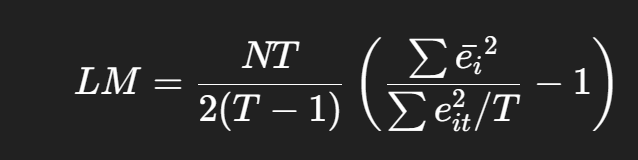

In [ ]:
# UJI LM BREUSCH–PAGAN (Pooled vs RE) dengan rumus manual
df_panel = df_panel.sort_index()

# Residual dari pooled model
e = pooled_model.resids

# Ambil ID entity dan group
entities = df_panel.index.get_level_values(0)  # Branch sebagai entity
T = df_panel.index.get_level_values(1).nunique()  # Jumlah waktu
N = entities.nunique()  # Jumlah branch

# Hitung mean residual per entity
import pandas as pd
e_series = pd.Series(e, index=df_panel.index)  # Pastikan residual ada index MultiIndex
e_means = e_series.groupby(entities).mean()

# Hitung LM statistic
numerator = N * T
denominator = 2 * (T - 1)
term = (e_means.pow(2).sum()) / (e_series.pow(2).sum() / T)

LM_stat = (numerator / denominator) * (term - 1)
LM_p = 1 - chi2.cdf(LM_stat, 1)

print("=== UJI LM BREUSCH-PAGAN (Pooled vs RE) ===")
print(f"LM-statistic : {LM_stat}")
print(f"p-value      : {LM_p}")

if LM_p < 0.05:
    print("Kesimpulan: RE lebih tepat daripada Pooled.\n")
else:
    print("Kesimpulan: Pooled lebih tepat.\n")

=== UJI LM BREUSCH-PAGAN (Pooled vs RE) ===
LM-statistic : -3.011576577929523
p-value      : 1.0
Kesimpulan: Pooled lebih tepat.



In [ ]:
print("=== KESIMPULAN MODEL TERBAIK ===")

model_chow = "FE" if p_chow < 0.05 else "Pooled"
model_hausman = "FE" if hausman_p < 0.05 else "RE"
model_lm = "RE" if LM_p < 0.05 else "Pooled"

print(f"Hasil Uji Chow   : {model_chow}")
print(f"Hasil Hausman    : {model_hausman}")
print(f"Hasil LM Test    : {model_lm}")

# Final rekomendasi
final_model = "FE" if model_hausman == "FE" else "RE"
print(f"\nModel terbaik berdasarkan keseluruhan uji: {final_model}")

=== KESIMPULAN MODEL TERBAIK ===
Hasil Uji Chow   : FE
Hasil Hausman    : RE
Hasil LM Test    : Pooled

Model terbaik berdasarkan keseluruhan uji: RE


### Bangun Model

In [ ]:
# Model Random Effects (RE) dengan Clustered SE per Entity
re_model_cluster = RandomEffects(y, X).fit(
    cov_type='clustered',   # clustered standard errors
    cluster_entity=True      # cluster per entity (Product line)
)

print("\n============= MODEL RANDOM EFFECTS (RE) DENGAN CLUSTERED SE PER ENTITY =============")
print(re_model_cluster.summary)


============= MODEL RANDOM EFFECTS (RE) DENGAN CLUSTERED SE PER ENTITY =============
                        RandomEffects Estimation Summary                        
Dep. Variable:           gross income   R-squared:                        0.8865
Estimator:              RandomEffects   R-squared (Between):              0.7922
No. Observations:                 454   R-squared (Within):               0.8868
Date:                Thu, Dec 04 2025   R-squared (Overall):              0.8865
Time:                        05:22:38   Log-likelihood                   -1153.3
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1760.8
Entities:                           6   P-value                           0.0000
Avg Obs:                       75.667   Distribution:                   F(2,451)
Min Obs:                       73.000                                           
Max Obs:               

Persamaan Model Regresi:

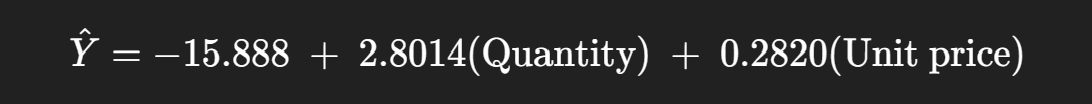

### Uji Asumsi Model RE

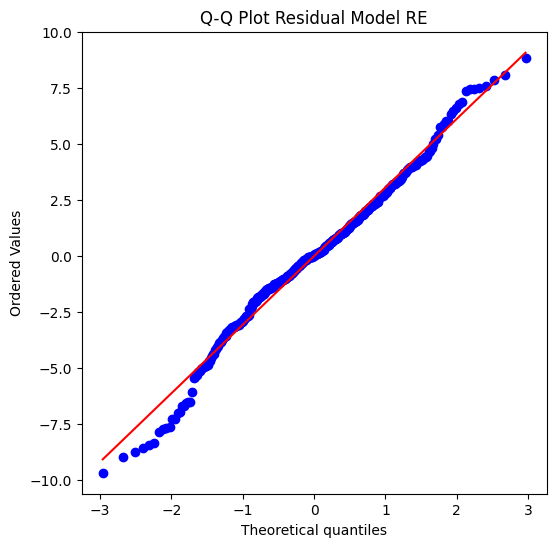

===== Shapiro-Wilk Test =====
Statistic: 0.9860, p-value: 0.0002


In [ ]:
# Uji Normalitas Residual
# Ambil residual dari model RE
residuals = re_model_cluster.resids  # gunakan model RE dengan clustered SE

# Visualisasi: Q-Q Plot
plt.figure(figsize=(6,6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot Residual Model RE")
plt.show()

# Shapiro-Wilk Test
shapiro_test = stats.shapiro(residuals)
print("===== Shapiro-Wilk Test =====")
print(f"Statistic: {shapiro_test[0]:.4f}, p-value: {shapiro_test[1]:.4f}")

H₀: Residual berdistribusi normal

> p-value < 0.05 → tolak H₀ → residual tidak normal

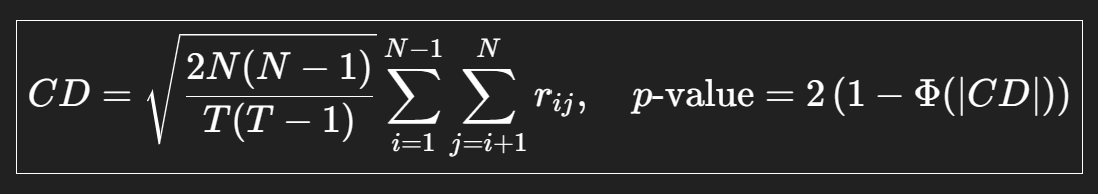

In [ ]:
# Uji Cross-section Dependence (Perhitungan Manual)
# Residual dari model RE
residuals = re_model_cluster.resids
# Reset index untuk mempermudah manipulasi
resid_df = residuals.reset_index()
resid_df = resid_df.rename(columns={0: 'residual'})
# Pivot table: rows = time, columns = entity
resid_pivot = resid_df.pivot(index='Date', columns='Product line', values='residual')
# Jumlah entitas (N) dan periode (T)
N = resid_pivot.shape[1]
T = resid_pivot.shape[0]
# Hitung korelasi pairwise antar entitas
r_ij = resid_pivot.corr().values
# Hilangkan diagonal (korelasi diri sendiri)
mask = ~np.eye(N, dtype=bool)
r_ij_flat = r_ij[mask]
# Pesaran CD Statistic
CD_stat = np.sqrt(2 * N * (N - 1) / (T * (T - 1))) * np.sum(r_ij_flat)
p_value = 2 * (1 - norm.cdf(np.abs(CD_stat)))

print("===== Pesaran Cross-sectional Dependence Test (Manual) =====")
print(f"CD Statistic: {CD_stat:.4f}")
print(f"p-value: {p_value:.4f}")

===== Pesaran Cross-sectional Dependence Test (Manual) =====
CD Statistic: -0.0805
p-value: 0.9358


p-value < 0.05 → ada cross-sectional dependence

p-value ≥ 0.05 → residual antar entitas independen

### Uji Kelayakan Model

In [ ]:
# R-squared
print("===== R-squared =====")
print(f"Overall R-squared: {re_model_cluster.rsquared:.4f}")
print(f"Within R-squared: {re_model_cluster.rsquared_within:.4f}")
print(f"Between R-squared: {re_model_cluster.rsquared_between:.4f}")

# Uji t (parsial)
print("\n===== Uji t untuk Koefisien =====")
coef_table = re_model_cluster.summary.tables[1]  # tabel parameter
print(coef_table)

# Uji F (simultan)
print("\n===== Uji F =====")
f_stat = re_model_cluster.f_statistic
print(f"F-statistic: {f_stat.stat:.4f}")
print(f"p-value: {f_stat.pval:.4f}")


===== R-squared =====
Overall R-squared: 0.8865
Within R-squared: 0.8868
Between R-squared: 0.7922

===== Uji t untuk Koefisien =====
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const         -15.888     0.3627    -43.804     0.0000     -16.601     -15.175
Quantity       2.8014     0.0676     41.450     0.0000      2.6686      2.9343
Unit price     0.2820     0.0075     37.553     0.0000      0.2672      0.2967

===== Uji F =====
F-statistic: 1760.8141
p-value: 0.0000
